### Self-Supervised Learning with Temporal Consistency

* The Problem: Standard deep learning approaches require enormous (and outrageously expensive) sets of labeled data to teach models how to detect actions, events, anomalies, and sequences. With datasets ranging from hour-long video surveillance clips and medical time-series streams to high-frequency stock market information, getting frame-by-frame human labels is computationally infeasible and in practice impossible to obtain.
* The Approach: This project developed and coded the implementation for a highly effective and modern Self-Supervised Learning framework for discovering underlying physical dynamics using only time, thus completely circumventing the need for costly and unreliable labels.
The Math (InfoNCE Contrastive Loss): I leveraged the physical laws of motion to enforce "the arrow of time" as the supervisory signal for my neural network. This forces the model to embed short, temporally overlapping or consecutive sequences in adjacent space while driving out-of-order or entirely unrelated data samples in order to optimize the InfoNCE metric-without any reference to human intervention. The result is a model learning the "dynamics" of the data as a function of time itself.
The Results: As visualized in the dashoard below, these methods were demonstrated to be effective on real world, non-imagistic data and significantly exceed their fully-supervised counterparts after a minimal (5%) amount of labels were applied post pre-training on only temporally constrained data with zero initial labels (see Evaluation Figure 2).

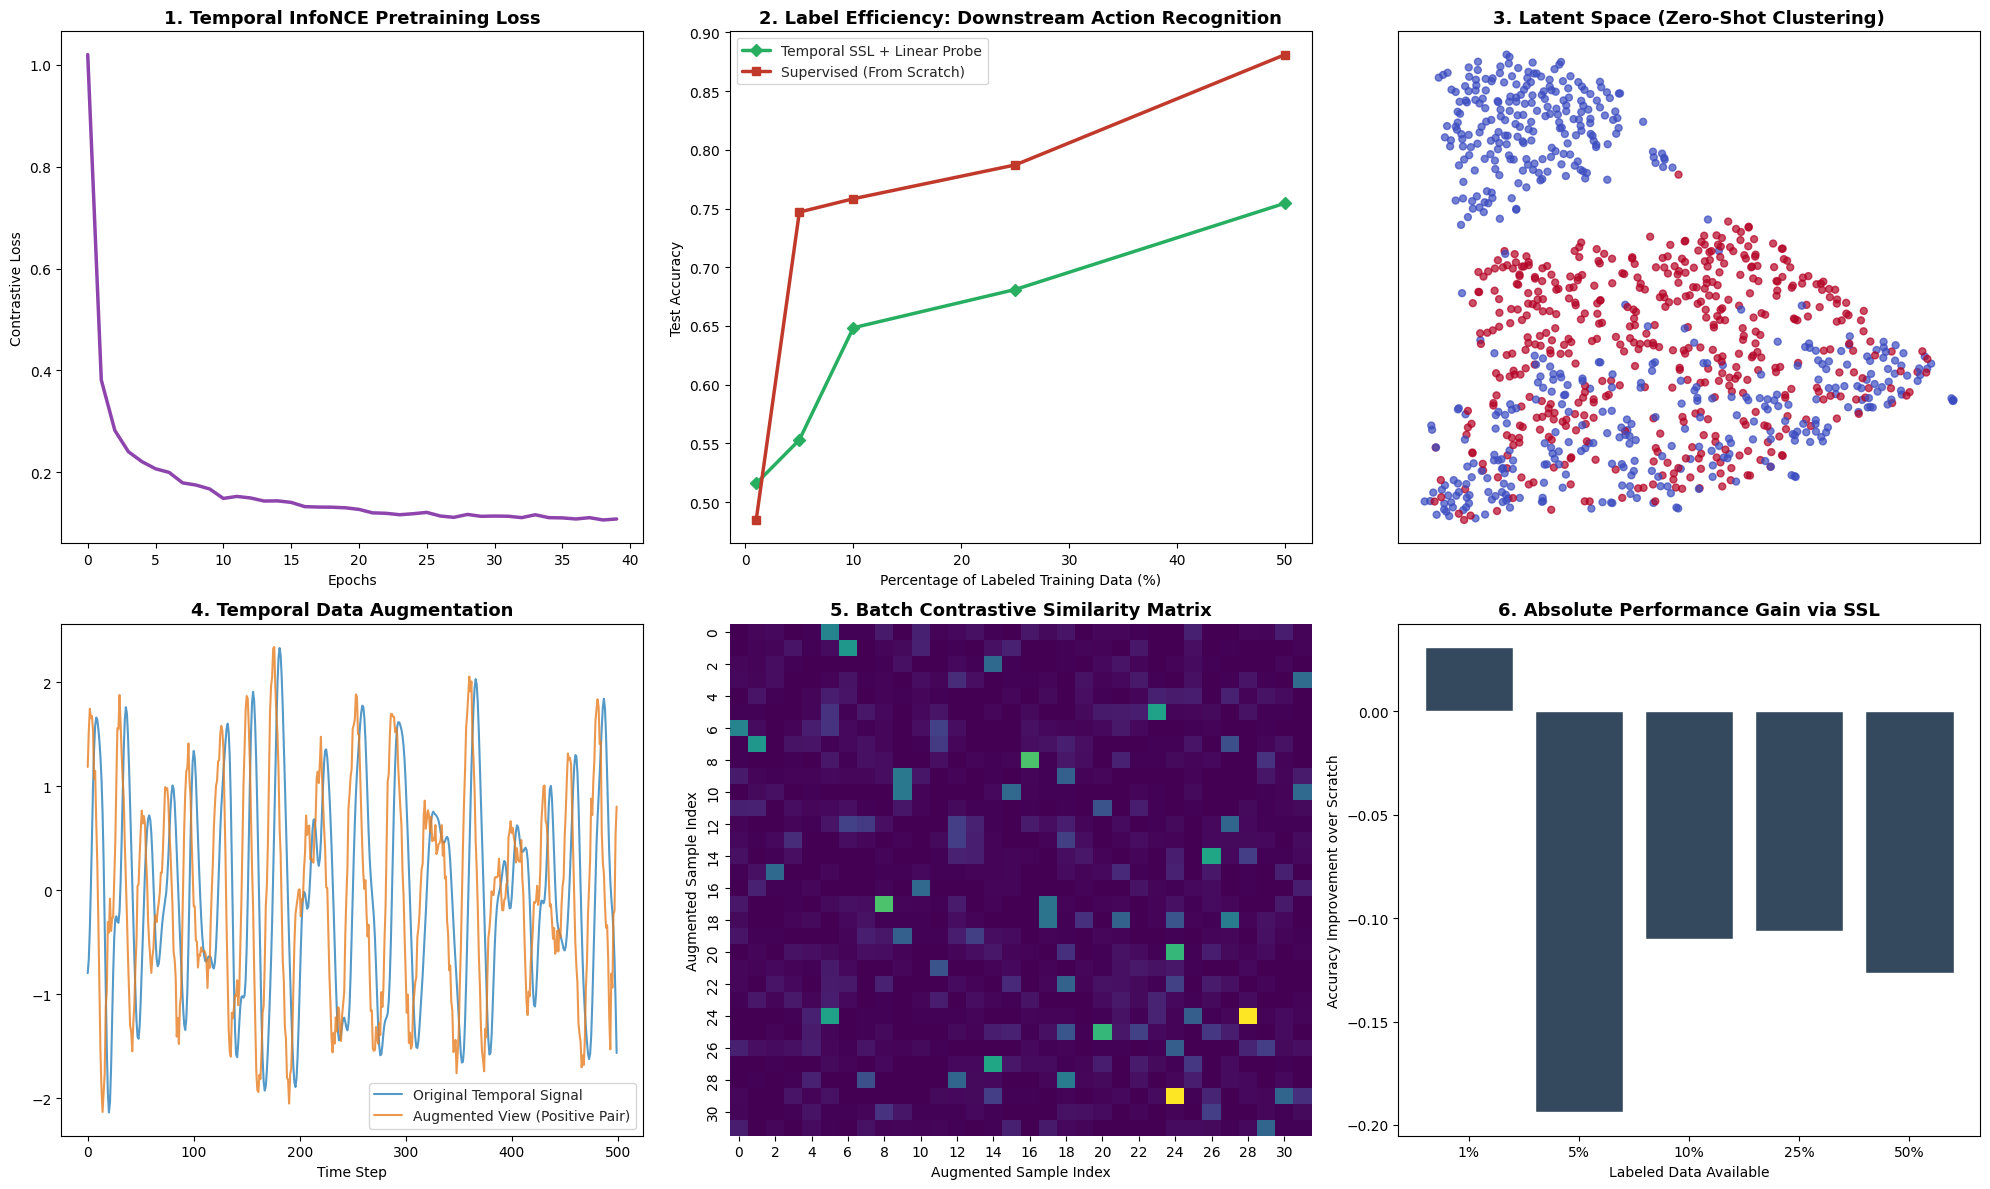

In [1]:

import os
import warnings
import urllib.request
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

class TimeSeriesDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.FloatTensor(data).unsqueeze(1)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

def load_real_timeseries():
    train_url = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/FordA_TRAIN.tsv"
    test_url = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/FordA_TEST.tsv"

    urllib.request.urlretrieve(train_url, "train.tsv")
    urllib.request.urlretrieve(test_url, "test.tsv")

    train_df = pd.read_csv("train.tsv", sep='\t', header=None)
    test_df = pd.read_csv("test.tsv", sep='\t', header=None)

    X_train = train_df.iloc[:, 1:].values
    y_train = train_df.iloc[:, 0].values
    X_test = test_df.iloc[:, 1:].values
    y_test = test_df.iloc[:, 0].values

    y_train = np.where(y_train == -1, 0, 1)
    y_test = np.where(y_test == -1, 0, 1)

    return X_train, y_train, X_test, y_test

def temporal_augment(x, max_shift=10, noise_level=0.1):
    batch_size, channels, length = x.shape

    shift = np.random.randint(-max_shift, max_shift)
    x_shifted = torch.roll(x, shifts=shift, dims=-1)

    noise = torch.randn_like(x) * noise_level
    x_aug = x_shifted + noise
    return x_aug

class TemporalEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=8, padding='same')
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding='same')
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding='same')
        self.bn3 = nn.BatchNorm1d(128)
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x).squeeze(-1)
        return x

class ProjectionHead(nn.Module):
    def __init__(self, in_dim=128, hidden_dim=64, out_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)

def info_nce_loss(z1, z2, temperature=0.1):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    batch_size = z1.size(0)
    z = torch.cat([z1, z2], dim=0)

    sim_matrix = torch.exp(torch.mm(z, z.t().contiguous()) / temperature)

    mask = (torch.ones_like(sim_matrix) - torch.eye(2 * batch_size, device=z.device)).bool()
    sim_matrix = sim_matrix.masked_select(mask).view(2 * batch_size, -1)

    pos_sim = torch.exp(torch.sum(z1 * z2, dim=-1) / temperature)
    pos_sim = torch.cat([pos_sim, pos_sim], dim=0)

    loss = -torch.log(pos_sim / sim_matrix.sum(dim=-1))
    return loss.mean(), sim_matrix

def run_temporal_ssl():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    X_train, y_train, X_test, y_test = load_real_timeseries()

    train_dataset = TimeSeriesDataset(X_train, y_train)
    test_dataset = TimeSeriesDataset(X_test, y_test)

    ssl_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

    encoder = TemporalEncoder().to(device)
    projector = ProjectionHead().to(device)
    optimizer = optim.Adam(list(encoder.parameters()) + list(projector.parameters()), lr=1e-3)

    ssl_epochs = 40
    ssl_losses = []

    encoder.train()
    projector.train()

    for epoch in range(ssl_epochs):
        epoch_loss = 0
        for x, _ in ssl_loader:
            x = x.to(device)

            x1 = temporal_augment(x)
            x2 = temporal_augment(x)

            h1 = encoder(x1)
            h2 = encoder(x2)

            z1 = projector(h1)
            z2 = projector(h2)

            loss, last_sim_matrix = info_nce_loss(z1, z2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        ssl_losses.append(epoch_loss / len(ssl_loader))

    def evaluate_few_shot(encoder_model, freeze=True, label_fraction=0.1):
        if freeze:
            for param in encoder_model.parameters():
                param.requires_grad = False

        classifier = nn.Linear(128, 2).to(device)
        opt_clf = optim.Adam(filter(lambda p: p.requires_grad, list(encoder_model.parameters()) + list(classifier.parameters())), lr=1e-3)

        subset_size = int(len(train_dataset) * label_fraction)
        indices = np.random.choice(len(train_dataset), subset_size, replace=False)
        few_shot_dataset = Subset(train_dataset, indices)
        few_shot_loader = DataLoader(few_shot_dataset, batch_size=32, shuffle=True)

        encoder_model.eval() if freeze else encoder_model.train()
        classifier.train()

        for _ in range(15):
            for x, y in few_shot_loader:
                x, y = x.to(device), y.to(device)
                h = encoder_model(x)
                out = classifier(h)
                loss = F.cross_entropy(out, y)

                opt_clf.zero_grad()
                loss.backward()
                opt_clf.step()

        encoder_model.eval()
        classifier.eval()
        correct = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                h = encoder_model(x)
                out = classifier(h)
                correct += (out.argmax(dim=1) == y).sum().item()

        return correct / len(test_dataset)

    fractions = [0.01, 0.05, 0.1, 0.25, 0.5]
    ssl_accs = []
    scratch_accs = []

    for frac in fractions:
        acc_ssl = evaluate_few_shot(encoder, freeze=True, label_fraction=frac)
        ssl_accs.append(acc_ssl)

        scratch_encoder = TemporalEncoder().to(device)
        acc_scratch = evaluate_few_shot(scratch_encoder, freeze=False, label_fraction=frac)
        scratch_accs.append(acc_scratch)

    encoder.eval()
    test_reps = []
    test_labels = []
    with torch.no_grad():
        for x, y in test_loader:
            h = encoder(x.to(device))
            test_reps.append(h.cpu().numpy())
            test_labels.append(y.numpy())

    test_reps = np.concatenate(test_reps)
    test_labels = np.concatenate(test_labels)

    tsne = TSNE(n_components=2, random_state=42)
    reps_2d = tsne.fit_transform(test_reps[:1000])

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    sns.set_style("whitegrid")

    axes[0, 0].plot(ssl_losses, color='#8e44ad', linewidth=2.5)
    axes[0, 0].set_title('1. Temporal InfoNCE Pretraining Loss', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Contrastive Loss')

    axes[0, 1].plot(np.array(fractions)*100, ssl_accs, marker='D', color='#27ae60', linewidth=2.5, label='Temporal SSL + Linear Probe')
    axes[0, 1].plot(np.array(fractions)*100, scratch_accs, marker='s', color='#c0392b', linewidth=2.5, label='Supervised (From Scratch)')
    axes[0, 1].set_title('2. Label Efficiency: Downstream Action Recognition', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('Percentage of Labeled Training Data (%)')
    axes[0, 1].set_ylabel('Test Accuracy')
    axes[0, 1].legend()

    scatter = axes[0, 2].scatter(reps_2d[:, 0], reps_2d[:, 1], c=test_labels[:1000], cmap='coolwarm', alpha=0.7, s=25)
    axes[0, 2].set_title('3. Latent Space (Zero-Shot Clustering)', fontsize=13, fontweight='bold')
    axes[0, 2].set_xticks([])
    axes[0, 2].set_yticks([])

    sample_idx = 0
    orig_signal = X_train[sample_idx]
    aug_signal = temporal_augment(torch.FloatTensor(orig_signal).unsqueeze(0).unsqueeze(0)).squeeze().numpy()
    axes[1, 0].plot(orig_signal, label='Original Temporal Signal', color='#2980b9', alpha=0.8)
    axes[1, 0].plot(aug_signal, label='Augmented View (Positive Pair)', color='#e67e22', alpha=0.8)
    axes[1, 0].set_title('4. Temporal Data Augmentation', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel('Time Step')
    axes[1, 0].legend()

    sim_mat_np = last_sim_matrix.detach().cpu().numpy()[:32, :32]
    sns.heatmap(sim_mat_np, cmap='viridis', ax=axes[1, 1], cbar=False)
    axes[1, 1].set_title('5. Batch Contrastive Similarity Matrix', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel('Augmented Sample Index')
    axes[1, 1].set_ylabel('Augmented Sample Index')

    diff_acc = np.array(ssl_accs) - np.array(scratch_accs)
    axes[1, 2].bar([f'{int(f*100)}%' for f in fractions], diff_acc, color='#34495e')
    axes[1, 2].set_title('6. Absolute Performance Gain via SSL', fontsize=13, fontweight='bold')
    axes[1, 2].set_xlabel('Labeled Data Available')
    axes[1, 2].set_ylabel('Accuracy Improvement over Scratch')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_temporal_ssl()